In [2]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# for everything else
import os
import numpy as np
import matplotlib.pyplot as plt
from random import randint
import pandas as pd
import pickle

import torch
import torch.nn as nn
from torchvision import models, transforms

from PIL import Image

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

import pytorch_lightning as pl
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from pytorch_lightning import Trainer
from RESNET101 import resnet101, ResNet101_Weights
import torch
import numpy as np
import cv2

from sklearn.preprocessing import LabelEncoder
from scipy.stats import mannwhitneyu
from scipy.optimize import linear_sum_assignment
import matplotlib.patches as mpatches
from sklearn.preprocessing import RobustScaler
import igraph as ig
import networkx as nx
import cairo
import community.community_louvain as cl
from sklearn.neighbors import kneighbors_graph
import sknetwork as skn
from sknetwork.clustering import Louvain
from sklearn.metrics import adjusted_rand_score
import seaborn as sns


from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import StratifiedKFold
import torch.optim as optim
import pytorch_lightning as pl
import umap

2025-06-16 15:41:07.361428: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-16 15:41:07.372590: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750102867.385928 1874693 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750102867.389901 1874693 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-16 15:41:07.404039: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [3]:
data_folder = '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2'
folders = ['group1', 'group2', 'group3', 'group4']
file_list = []
annotations = []

for folder in folders:
    folder_path = os.path.join(data_folder, folder)
    
    if os.path.exists(folder_path):
        #List all files in the folder
        files = os.listdir(folder_path)
        
        #Add filenames to the file_list and annotations to the annotations list
        file_list.extend([os.path.join(folder_path, file) for file in files])
        annotations.extend([folder] * len(files))

print("File List:", file_list)
print("Annotations:", annotations)    

print(len(file_list))
print(len(annotations))

File List: ['/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell11', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell5', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell7', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell6', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell13', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell8', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell12', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell10', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell16', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/cell18', '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/group1/

In [4]:
true_labels = np.array(annotations)

In [5]:
group_to_num = {'group1': 0, 'group2': 1, 'group3': 2, 'group4': 3}
numeric_labels = np.array([group_to_num[g] for g in true_labels])
unique_labels = set(numeric_labels)

In [6]:
transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

In [7]:
#Load the pre-trained ResNet101 model
resnet101 = models.resnet101(pretrained=True)

# Remove the final fully connected layer (fc) to get the 2048-dimensional feature vector
resnet101.fc = torch.nn.Identity()

/home/deev/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/deev/anaconda3/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [8]:
from PIL import Image, ImageOps

def prepare_image_with_padding_pil(image_path, target_size=(224, 224)):
    img = Image.open(image_path).convert('RGB') # Ensure 3 channels

    original_width, original_height = img.size
    target_width, target_height = target_size

    # Calculate scaling factor
    scale = min(target_width / original_width, target_height / original_height)

    # Calculate new dimensions
    new_width = int(original_width * scale)
    new_height = int(original_height * scale)

    # Resize the image while maintaining aspect ratio
    resized_img = img.resize((new_width, new_height), Image.LANCZOS) # High quality downsampling

    # Create a new blank image with the target size (e.g., 224x224)
    # and paste the resized image into its center, padding the rest.
    padded_img = Image.new('RGB', target_size, (0, 0, 0)) # Black padding
    
    # Calculate paste position for centering
    paste_x = (target_width - new_width) // 2
    paste_y = (target_height - new_height) // 2
    
    padded_img.paste(resized_img, (paste_x, paste_y))
    
    return padded_img

def extract_features(file, model):
    # Use the prepare_image_with_padding_pil function to get the 224x224 padded image
    input_image_padded = prepare_image_with_padding_pil(file, target_size=(224, 224))

    # Prepare image for model using the modified transform
    input_tensor = transform(input_image_padded)
    input_batch = input_tensor.unsqueeze(0) # Create a mini-batch as expected by the model

    # Get the feature vector and extract features
    with torch.no_grad():
        features = model(input_batch)

    return features

In [9]:
# Normalize each cell (row) so that the sum of gene counts per cell is 1
count_matrix = pd.read_csv("/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/count_matrix.csv", index_col=0)
scaled_counts_matrix = count_matrix.copy()
cm_counts_per_1 = scaled_counts_matrix.div(scaled_counts_matrix.sum(axis=1), axis=0)
# Remove underscores from the index to convert "cell_75" to "cell75"
cm_counts_per_1.index = cm_counts_per_1.index.str.replace("_", "", regex=False)
cm_counts_per_1.columns = cm_counts_per_1.columns.str.replace("_", "", regex=False)
cm_counts_per_1.to_csv('/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/cp1_count_matrix.csv', index=True)

In [10]:
print(cm_counts_per_1.head())

       gene1  gene2  gene3
cell1    1.0    0.0    0.0
cell2    1.0    0.0    0.0
cell3    1.0    0.0    0.0
cell4    1.0    0.0    0.0
cell5    1.0    0.0    0.0


In [110]:
from sklearn.metrics import jaccard_score
from sklearn.preprocessing import LabelEncoder

def calculate_jaccard_similarity(cluster_labels, annotations):
    # Encode labels as integers
    le = LabelEncoder()
    cluster_labels_encoded = le.fit_transform(cluster_labels)
    label1 = le.classes_
    annotations_encoded = le.fit_transform(annotations)
    label2 = le.classes_

    # Calculate Jaccard similarity matrix
    n_label1 = len(label1)
    n_label2 = len(label2)
    jaccard_matrix = np.zeros((n_label1, n_label2))

    for i in range(n_label1):
        for j in range(n_label2):
            jaccard_matrix[i, j] = jaccard_score(cluster_labels_encoded == i, annotations_encoded == j)

    return jaccard_matrix, label1, label2

def plot_heatmap(similarity_matrix, labels1, labels2):
    plt.figure(figsize=(10, 8))
    plt.imshow(similarity_matrix, cmap='viridis', aspect='auto')
    plt.colorbar(label='Jaccard Similarity')
    plt.xticks(range(len(labels1)), labels1, rotation=45, ha='right')
    plt.yticks(range(len(labels2)), labels2)
    plt.xlabel('Annotations')
    plt.ylabel('Cluster Labels')
    plt.title('Jaccard Similarity Heatmap')
    plt.tight_layout()
    plt.show()


## No Feature Weighting

In [11]:
features_stack = []
images_order = [] # To track (cell_id, [list of hybridizations])
count_matrix = pd.read_csv("/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/cp1_count_matrix.csv", index_col=0)
count_matrix.index = count_matrix.index.astype(str)
gene_hybridization_names = list(count_matrix.columns) 


for img in file_list:
    features_list = []
    hybridizations_list = [] 
    # Extract the cell identifier from the file path
    cell_id = img.split('/')[-1]  # e.g., "3243", "1560"

    #Get counts for this cell (full hybridization names remain)
    #counts = count_matrix.loc[cell_id]

    for file in os.listdir(img):
        #Skip segmentation files
        if "cell_seg" in file:
            continue
        # Track if a valid gene hybridization was found
        matched = False

        for hybridization in gene_hybridization_names:  # Loop through full hybridization names
            if hybridization in file: #Check if the exact hybridization is in the filename
                #feat = extract_features(os.path.join(img, file), resnet101) * counts[hybridization]
                feat = extract_features(os.path.join(img, file), resnet101)
                features_list.append(np.array(feat.squeeze()))
                hybridizations_list.append(hybridization)
                matched = True
                break  # Stop searching once we find a match
        #If no valid gene hybridization was found in this file, print a warning
        if not matched:
            print(os.path.join(img, file))
            print(f"Warning: Unmatched file (not a gene hybridization) → {file}")
    

    if features_list:  #Ensure features exist before concatenation
        features_stack.append(np.concatenate(features_list, axis=0))
        images_order.append((cell_id, hybridizations_list))  # Track cell ID & hybridizations
        

# convert list to numpy array
# onvert list to numpy array
features_stack = np.stack(features_stack)
print(features_stack.shape)

(80, 6144)


In [12]:
#Perform PCA
pca = PCA(n_components=5, random_state=22)
pca.fit(features_stack)
pcs = pca.transform(features_stack)

In [13]:
#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

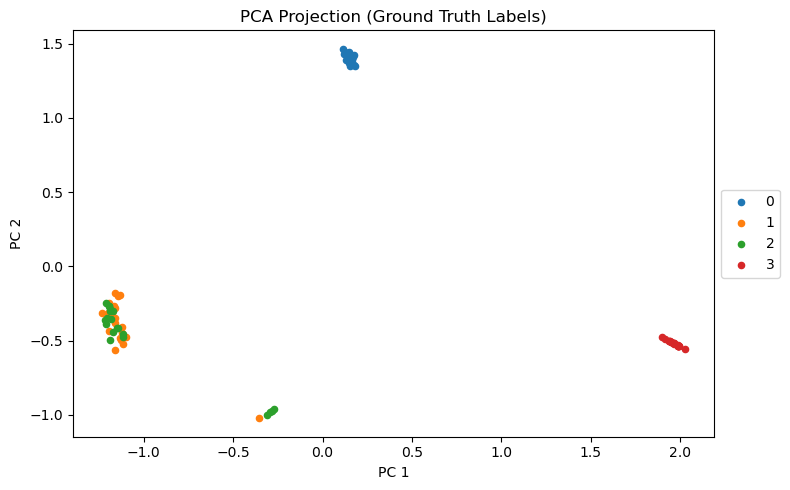

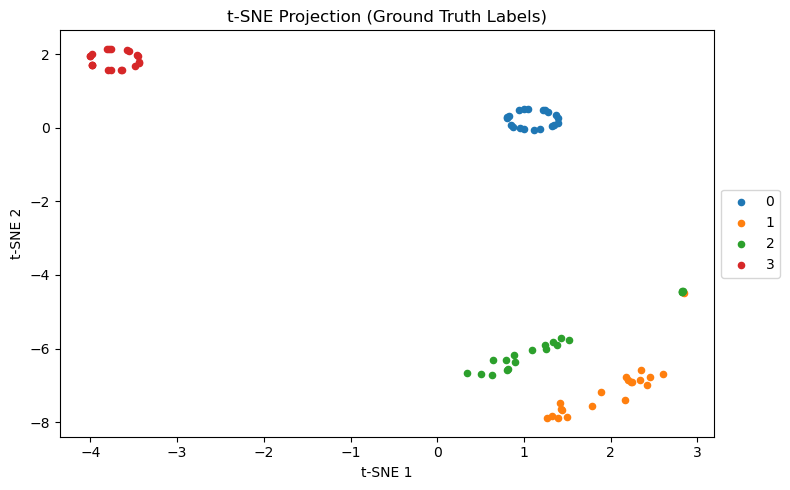

In [14]:
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [15]:
from sklearn.cluster import KMeans
#Number of clusters
n_clusters = 4

#Perform k-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(pcs)

In [16]:
category_color_mapping = {
    'group1': 'red',
    'group2': 'green',
    'group3': 'orange',
    'group4': 'blue',
}

color_vector = np.array([category_color_mapping[i] for i in annotations])

len(annotations)

80

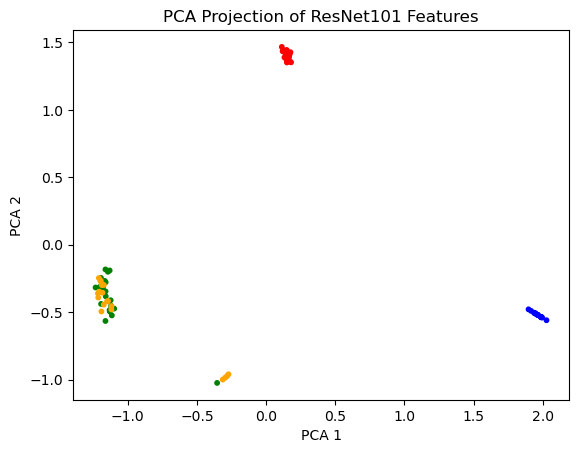

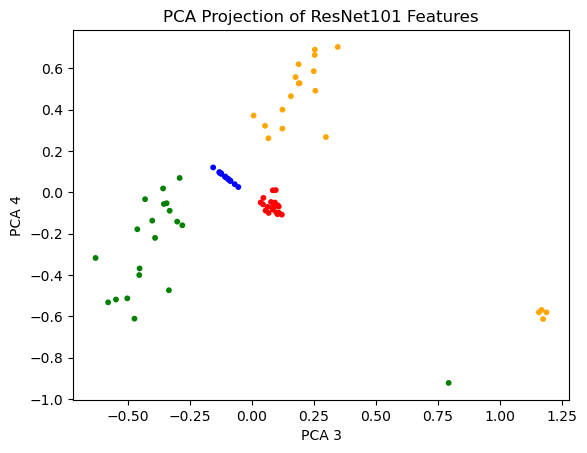

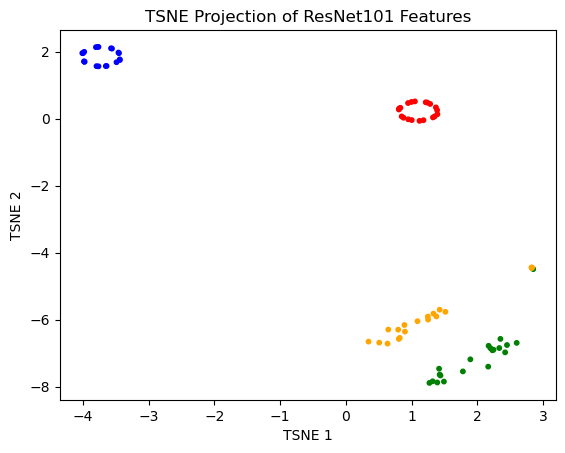

In [17]:
plt.scatter(pcs[:, 0], pcs[:, 1], c=color_vector, marker='o', s=10)
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

plt.scatter(pcs[:, 2], pcs[:, 3], c=color_vector, marker='o', s=10)
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 3')
plt.ylabel('PCA 4')
plt.show()

plt.scatter(embedding[:, 0], embedding[:, 1], c=color_vector, marker='o', s=10)
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.show()

/tmp/ipykernel_1874693/1399701563.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


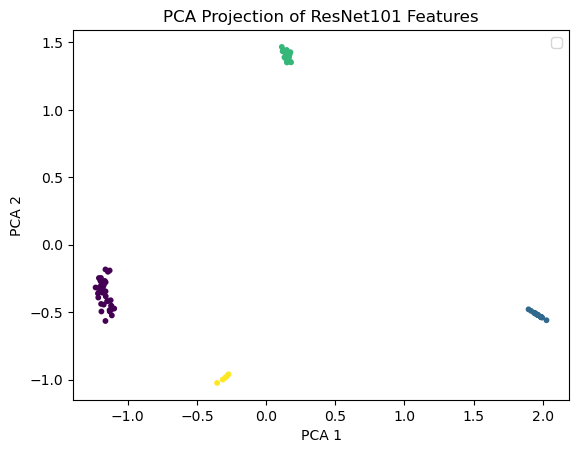

/tmp/ipykernel_1874693/1399701563.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


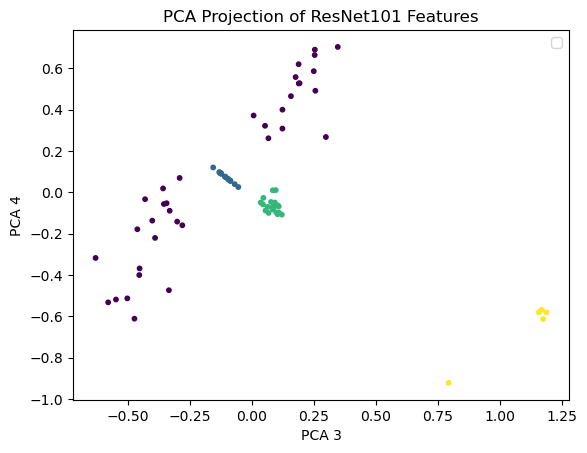

/tmp/ipykernel_1874693/1399701563.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


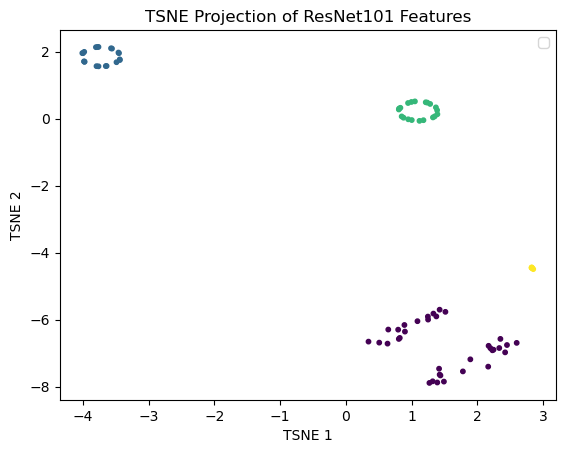

In [18]:
plt.scatter(pcs[:, 0], pcs[:, 1], c=cluster_labels, marker='o', s=10)
plt.legend()
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

plt.scatter(pcs[:, 2], pcs[:, 3], c=cluster_labels, marker='o', s=10)
plt.title('PCA Projection of ResNet101 Features')
plt.legend()
plt.xlabel('PCA 3')
plt.ylabel('PCA 4')
plt.show()

plt.scatter(embedding[:, 0], embedding[:, 1], c=cluster_labels, marker='o', s=10)
plt.title('TSNE Projection of ResNet101 Features')
plt.legend()
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.show()

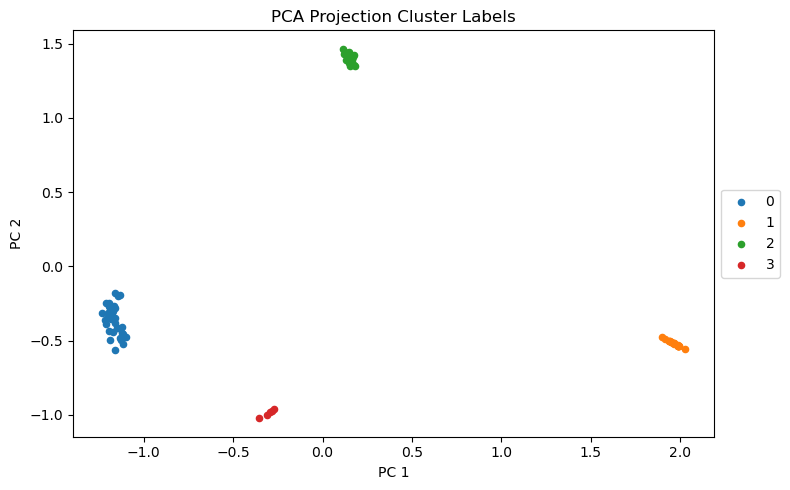

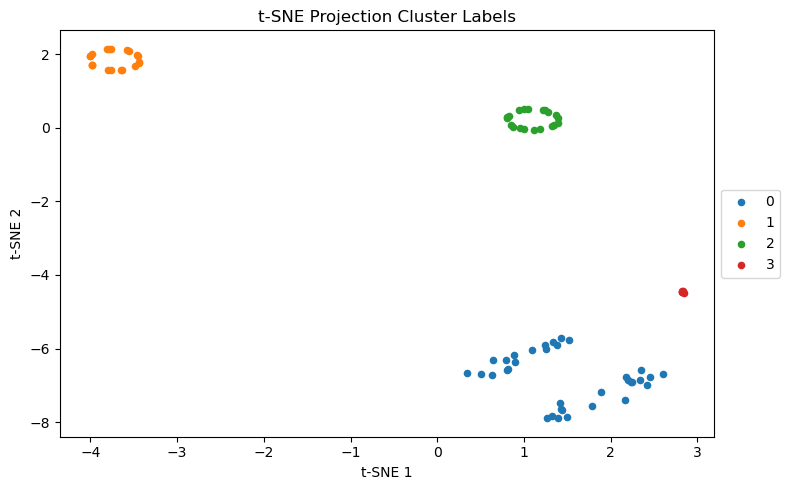

In [19]:
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (cluster_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection Cluster Labels')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    mask = (cluster_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection Cluster Labels')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [20]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 35 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 5 data points


In [21]:
cluster_labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 3, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 0, 0, 0, 0, 3, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

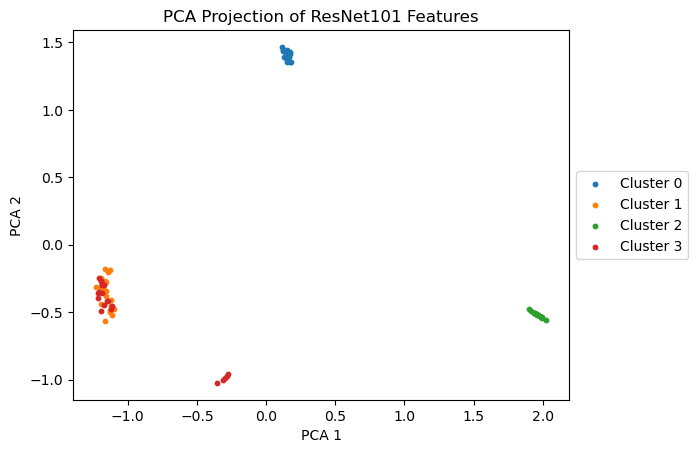

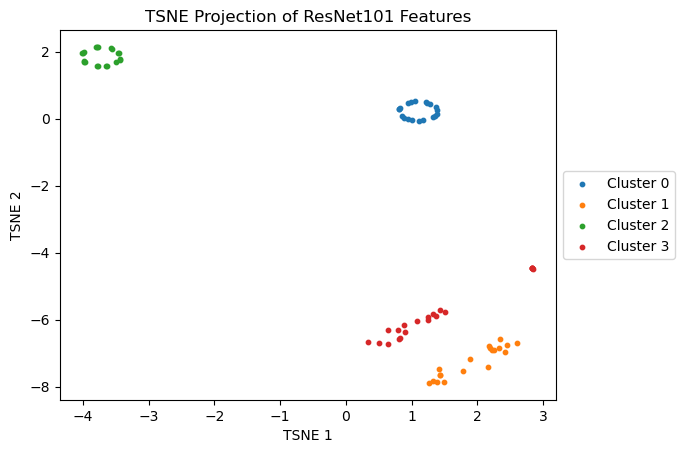

In [22]:
#Construct a k-Nearest Neighbors graph
knn_graph = kneighbors_graph(pcs, n_neighbors=10, metric='cosine', mode='connectivity', include_self=True)
#Convert the sparse matrix to a graph
G = nx.from_scipy_sparse_array(knn_graph)
# Perform Louvain clustering
partition = cl.best_partition(G)
#Compute the modularity of a partition of a graph
cl.modularity(partition, G)
#Extract cluster labels
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # PCA 1 values for this cluster
        embedding[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [23]:
for label in unique_labels_2:
    count = np.sum(cluster_labels == label)
    print(f"Cluster {label}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 19 data points
Cluster 2: 20 data points
Cluster 3: 21 data points


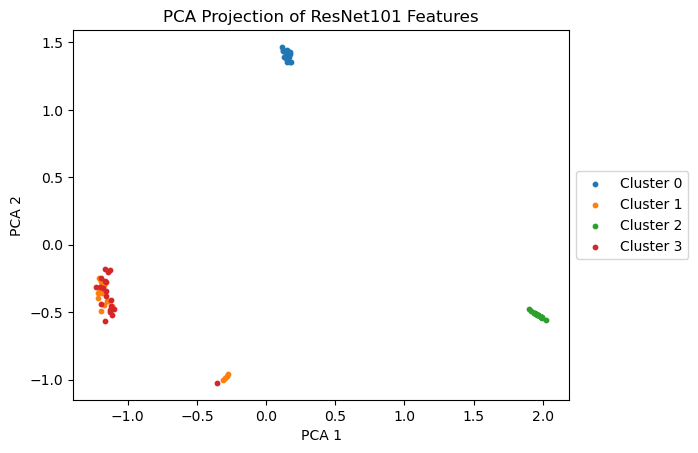

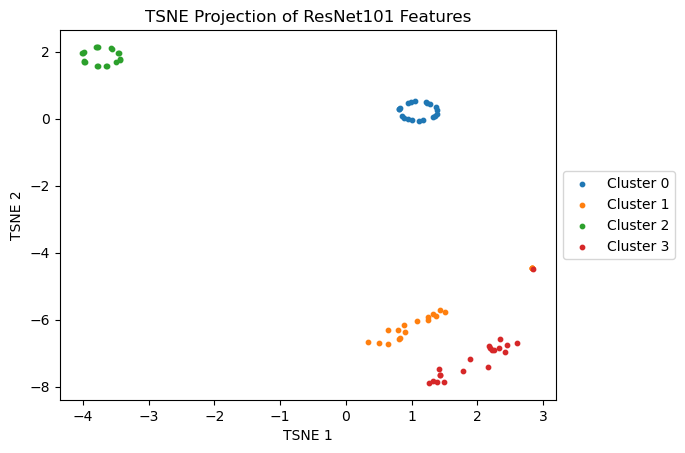

In [24]:
#Construct a k-Nearest Neighbors graph
knn_graph = kneighbors_graph(pcs, n_neighbors=20, metric='cosine', mode='connectivity', include_self=True)
#Convert the sparse matrix to a graph
G = nx.from_scipy_sparse_array(knn_graph)
# Perform Louvain clustering
partition = cl.best_partition(G)
#Compute the modularity of a partition of a graph
cl.modularity(partition, G)
#Extract cluster labels
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # PCA 1 values for this cluster
        embedding[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [25]:
for label in unique_labels_2:
    count = np.sum(cluster_labels == label)
    print(f"Cluster {label}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 20 data points


## Feature Weighting

## Counts Per 1

In [26]:
features_stack = []
images_order = [] # To track (cell_id, [list of hybridizations])
count_matrix = pd.read_csv("/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/cp1_count_matrix.csv", index_col=0)
count_matrix.index = count_matrix.index.astype(str)
gene_hybridization_names = list(count_matrix.columns) 


for img in file_list:
    features_list = []
    hybridizations_list = [] 
    # Extract the cell identifier from the file path
    cell_id = img.split('/')[-1]  # e.g., "3243", "1560"

    #Get counts for this cell (full hybridization names remain)
    counts = count_matrix.loc[cell_id]

    for file in os.listdir(img):
        #Skip segmentation files
        if "cell_seg" in file:
            continue
        # Track if a valid gene hybridization was found
        matched = False

        for hybridization in gene_hybridization_names:  # Loop through full hybridization names
            if hybridization in file: #Check if the exact hybridization is in the filename
                feat = extract_features(os.path.join(img, file), resnet101) * counts[hybridization]
                features_list.append(np.array(feat.squeeze()))
                hybridizations_list.append(hybridization)
                matched = True
                break  # Stop searching once we find a match
        #If no valid gene hybridization was found in this file, print a warning
        if not matched:
            print(os.path.join(img, file))
            print(f"Warning: Unmatched file (not a gene hybridization) → {file}")
    

    if features_list:  #Ensure features exist before concatenation
        features_stack.append(np.concatenate(features_list, axis=0))
        images_order.append((cell_id, hybridizations_list))  # Track cell ID & hybridizations
        

# convert list to numpy array
# onvert list to numpy array
features_stack = np.stack(features_stack)
print(features_stack.shape)

(80, 6144)


In [27]:
#Perform PCA
pca = PCA(n_components=5, random_state=22)
pca.fit(features_stack)
pcs = pca.transform(features_stack)

In [28]:
#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

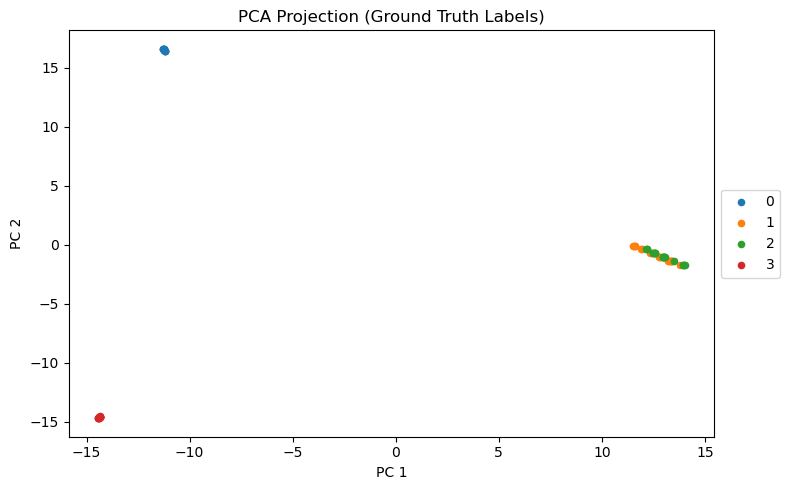

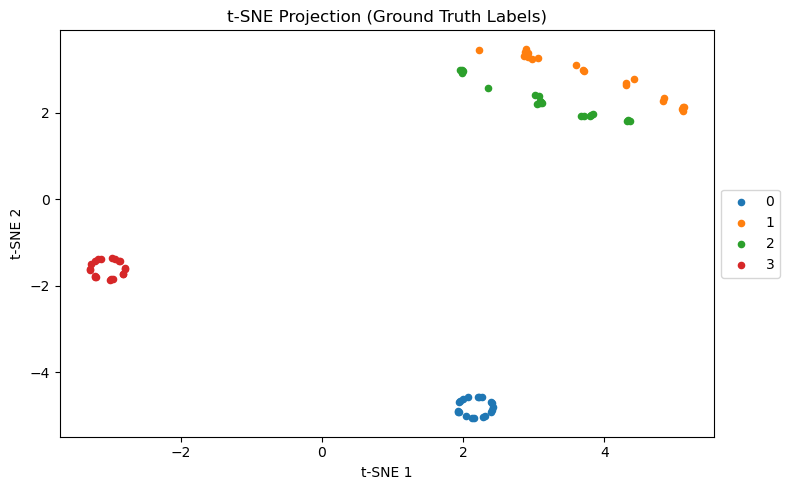

In [29]:
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [30]:
from sklearn.cluster import KMeans
#Number of clusters
n_clusters = 4

#Perform k-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(pcs)

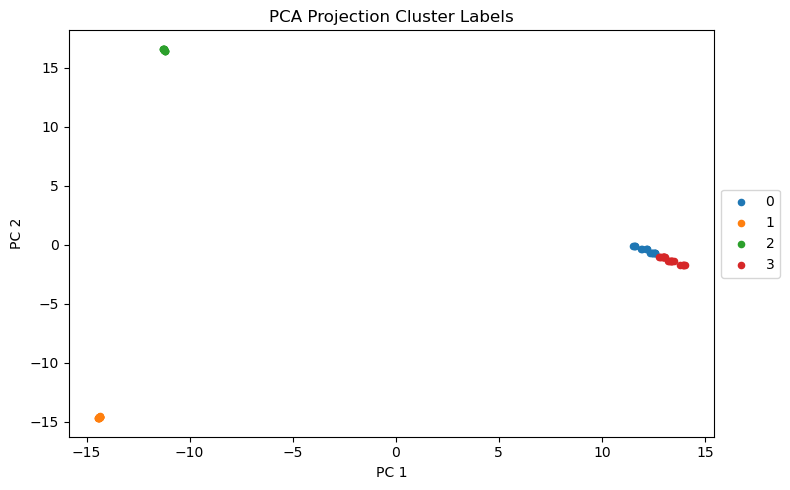

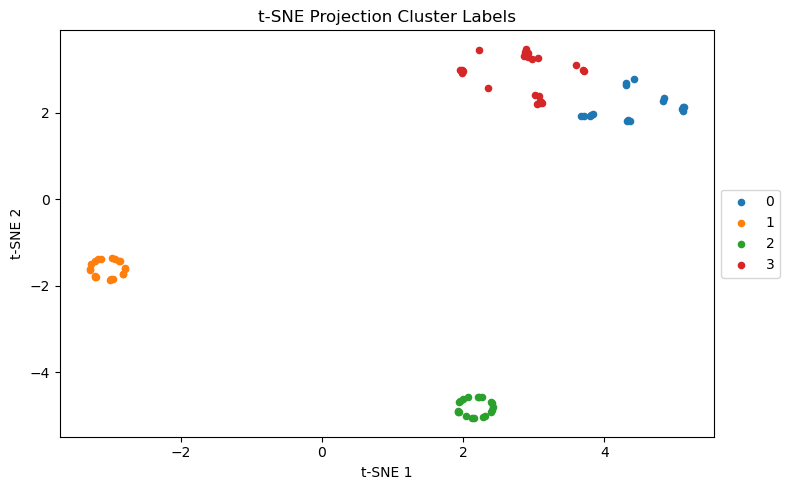

In [31]:
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (cluster_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection Cluster Labels')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    mask = (cluster_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection Cluster Labels')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [32]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 17 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 23 data points


In [33]:
cluster_labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 3,
       3, 0, 0, 3, 3, 0, 3, 0, 0, 0, 3, 0, 3, 3, 3, 0, 3, 3, 3, 3, 0, 3,
       3, 0, 3, 3, 3, 0, 3, 0, 0, 3, 3, 0, 0, 3, 0, 3, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

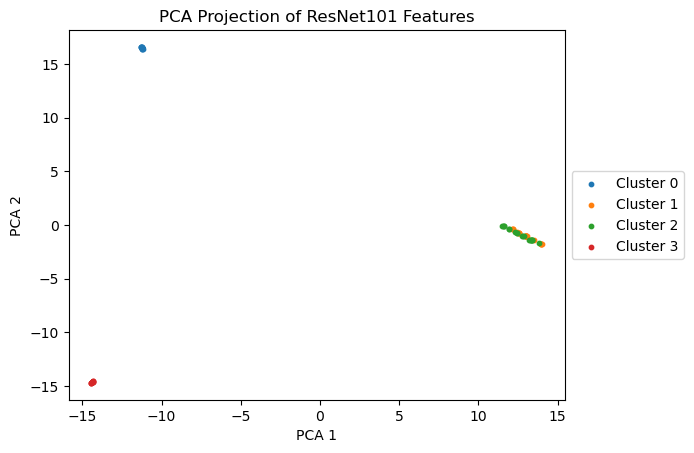

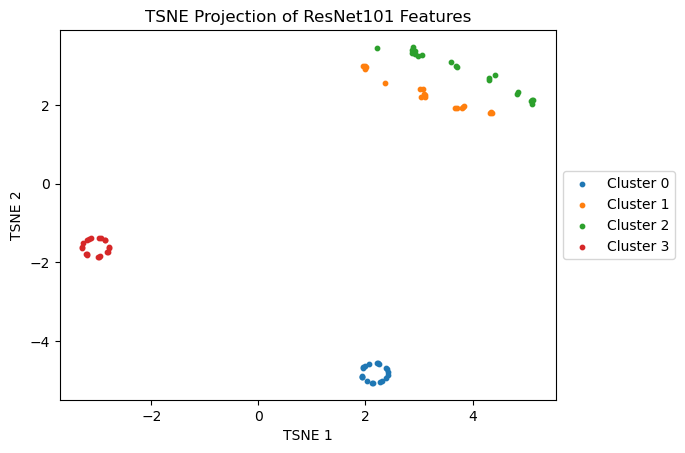

In [34]:
#Construct a k-Nearest Neighbors graph
knn_graph = kneighbors_graph(pcs, n_neighbors=10, metric='cosine', mode='connectivity', include_self=True)
#Convert the sparse matrix to a graph
G = nx.from_scipy_sparse_array(knn_graph)
# Perform Louvain clustering
partition = cl.best_partition(G)
#Compute the modularity of a partition of a graph
cl.modularity(partition, G)
#Extract cluster labels
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # PCA 1 values for this cluster
        embedding[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

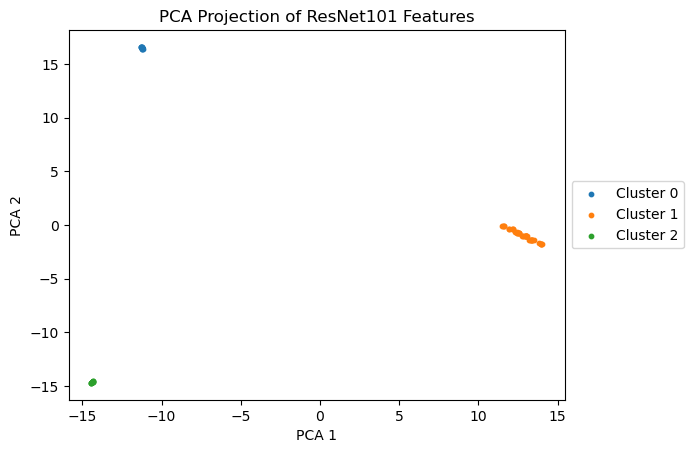

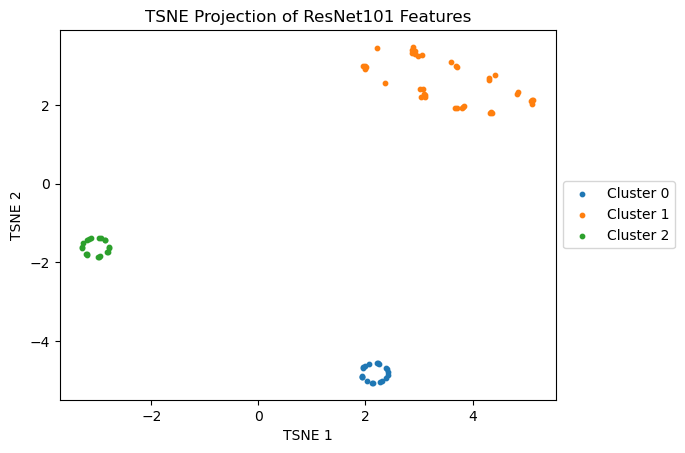

In [35]:
#Construct a k-Nearest Neighbors graph
knn_graph = kneighbors_graph(pcs, n_neighbors=20, metric='cosine', mode='connectivity', include_self=True)
#Convert the sparse matrix to a graph
G = nx.from_scipy_sparse_array(knn_graph)
# Perform Louvain clustering
partition = cl.best_partition(G)
#Compute the modularity of a partition of a graph
cl.modularity(partition, G)
#Extract cluster labels
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # PCA 1 values for this cluster
        embedding[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [36]:
for label in unique_labels_2:
    count = np.sum(cluster_labels == label)
    print(f"Cluster {label}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 40 data points
Cluster 2: 20 data points


## Feature Weighting 
## Min-Max

In [37]:
cm = '/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/count_matrix.csv'
counts_matrix = pd.read_csv(cm, index_col=0)
counts_matrix.index = counts_matrix.index.str.replace('_', '', regex=False)
counts_matrix.columns = counts_matrix.columns.str.replace('_', '', regex=False)
# Apply min-max scaling
def min_max_scaling(df):
    return (df - df.min()) / (df.max() - df.min())

scaled_counts_matrix = counts_matrix.copy()
scaled_counts_matrix = min_max_scaling(counts_matrix)
scaled_counts_matrix.to_csv('/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/min-max_count_matrix.csv', index=True)

In [38]:
scaled_counts_matrix

,gene1,gene2,gene3
cell1,1.0,0.0,0.0
cell2,1.0,0.0,0.0
cell3,1.0,0.0,0.0
cell4,1.0,0.0,0.0
cell5,1.0,0.0,0.0
...,...,...,...
cell76,0.0,0.0,1.0
cell77,0.0,0.0,1.0
cell78,0.0,0.0,1.0
cell79,0.0,0.0,1.0


In [39]:
features_stack = []
images_order = [] # To track (cell_id, [list of hybridizations])
count_matrix = pd.read_csv("/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/min-max_count_matrix.csv", index_col=0)
count_matrix.index = count_matrix.index.astype(str)
gene_hybridization_names = list(count_matrix.columns) 


for img in file_list:
    features_list = []
    hybridizations_list = [] 
    # Extract the cell identifier from the file path
    cell_id = img.split('/')[-1]  # e.g., "3243", "1560"

    #Get counts for this cell (full hybridization names remain)
    counts = count_matrix.loc[cell_id]

    for file in os.listdir(img):
        #Skip segmentation files
        if "cell_seg" in file:
            continue
        # Track if a valid gene hybridization was found
        matched = False

        for hybridization in gene_hybridization_names:  # Loop through full hybridization names
            if hybridization in file: #Check if the exact hybridization is in the filename
                feat = extract_features(os.path.join(img, file), resnet101) * counts[hybridization]
                features_list.append(np.array(feat.squeeze()))
                hybridizations_list.append(hybridization)
                matched = True
                break  # Stop searching once we find a match
        #If no valid gene hybridization was found in this file, print a warning
        if not matched:
            print(os.path.join(img, file))
            print(f"Warning: Unmatched file (not a gene hybridization) → {file}")
    

    if features_list:  #Ensure features exist before concatenation
        features_stack.append(np.concatenate(features_list, axis=0))
        images_order.append((cell_id, hybridizations_list))  # Track cell ID & hybridizations
        

# convert list to numpy array
# onvert list to numpy array
features_stack = np.stack(features_stack)
print(features_stack.shape)

(80, 6144)


In [40]:
#Perform PCA
pca = PCA(n_components=5, random_state=22)
pca.fit(features_stack)
pcs = pca.transform(features_stack)

In [41]:
#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

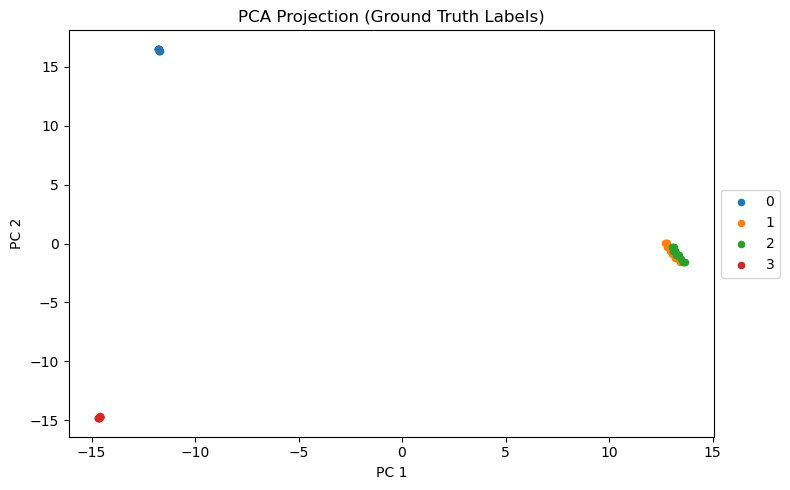

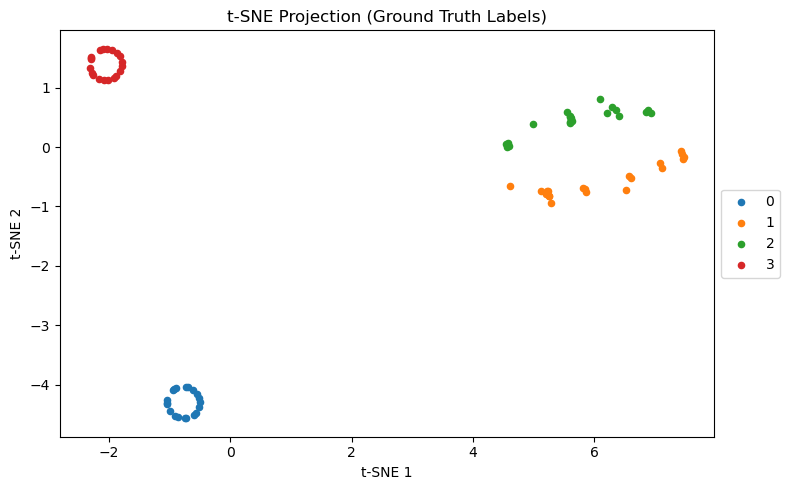

In [42]:
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [43]:
#Number of clusters
n_clusters = 4

#Perform k-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(pcs)

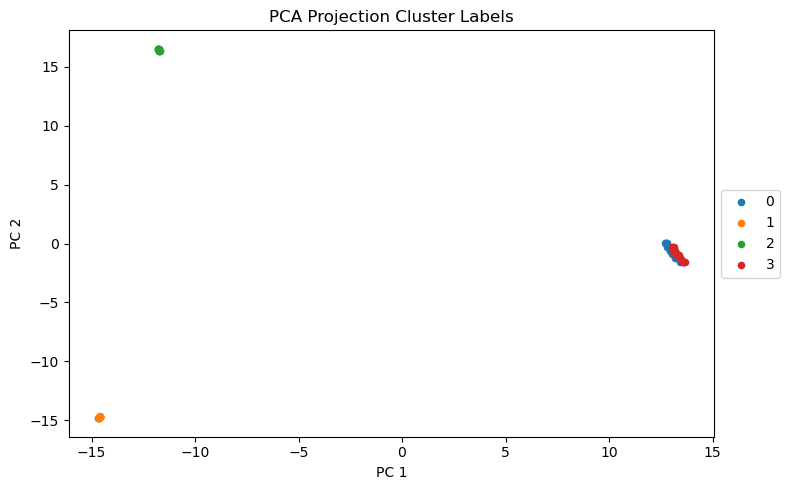

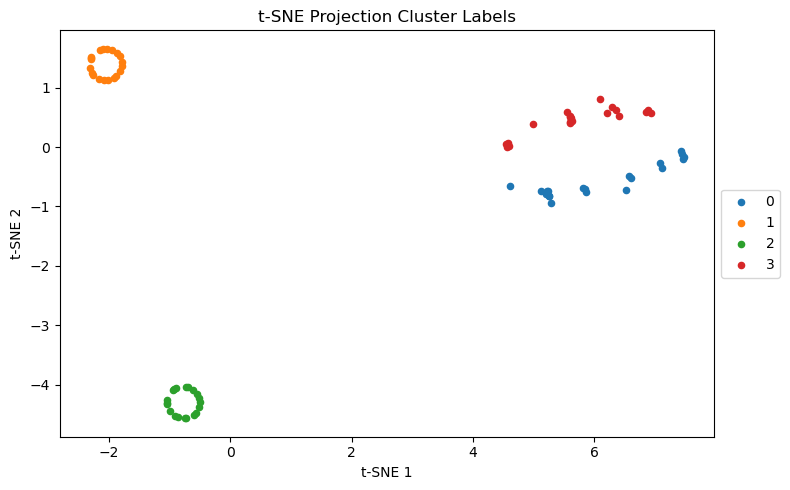

In [44]:
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (cluster_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection Cluster Labels')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    mask = (cluster_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection Cluster Labels')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [45]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 20 data points


In [46]:
cluster_labels

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

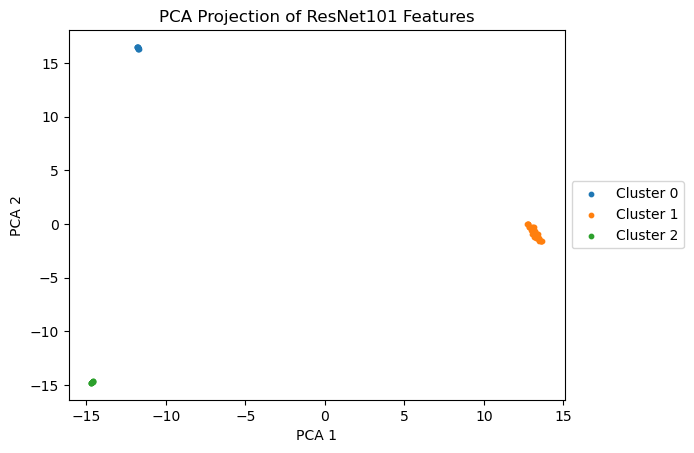

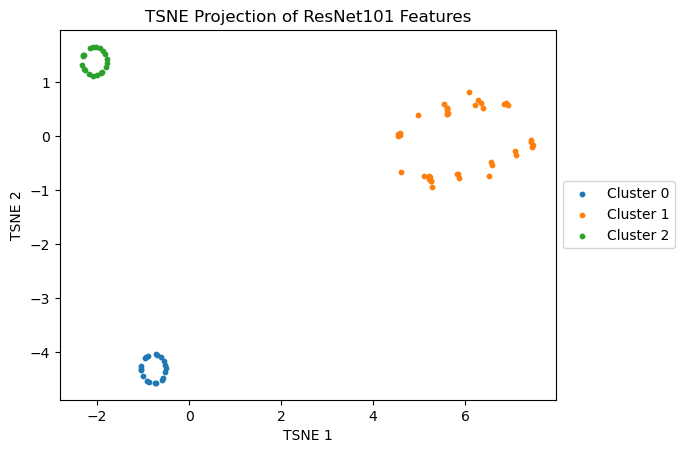

In [47]:
#Construct a k-Nearest Neighbors graph
knn_graph = kneighbors_graph(pcs, n_neighbors=20, metric='cosine', mode='connectivity', include_self=True)
#Convert the sparse matrix to a graph
G = nx.from_scipy_sparse_array(knn_graph)
# Perform Louvain clustering
partition = cl.best_partition(G)
#Compute the modularity of a partition of a graph
cl.modularity(partition, G)
#Extract cluster labels
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # PCA 1 values for this cluster
        embedding[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [48]:
for label in unique_labels_2:
    count = np.sum(cluster_labels == label)
    print(f"Cluster {label}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 40 data points
Cluster 2: 20 data points


## Just Gene Counts

## Raw Counts

In [104]:
count_matrix = pd.read_csv("/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/count_matrix.csv", index_col=0)
#Perform PCA
pca = PCA(n_components=3, random_state=22)
pca.fit(count_matrix)
pcs = pca.transform(count_matrix)

In [105]:
#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

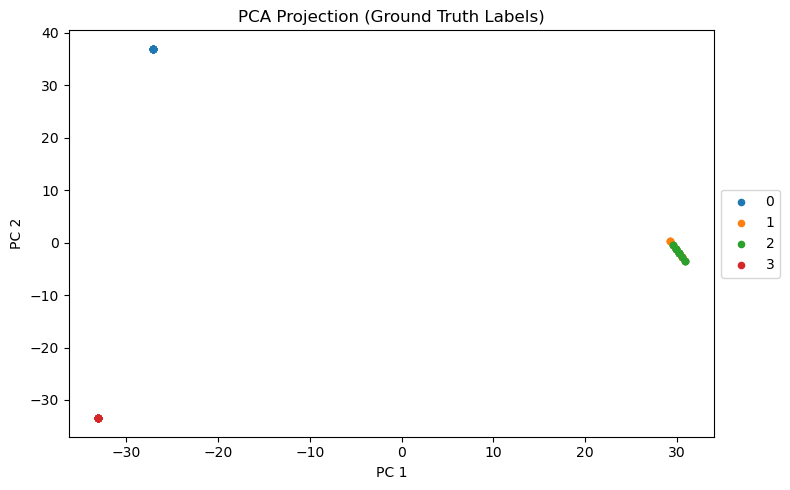

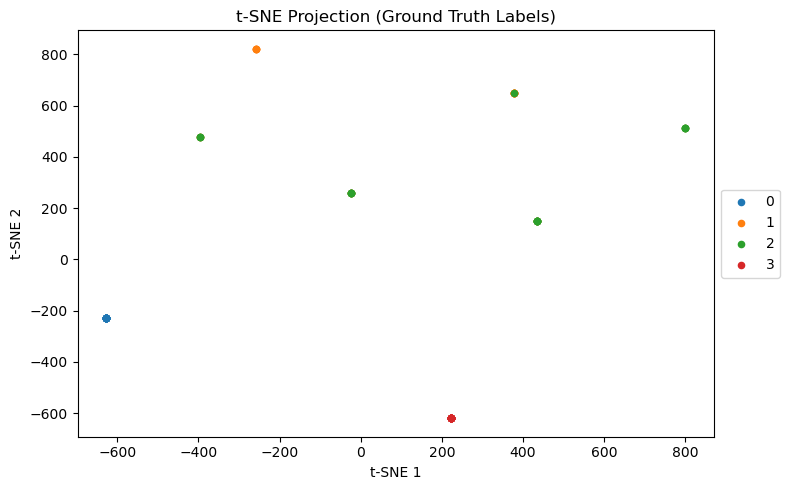

In [106]:
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [107]:
for label in np.unique(numeric_labels):
    count = np.sum(numeric_labels == label)
    print(f"Cluster {label}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 20 data points


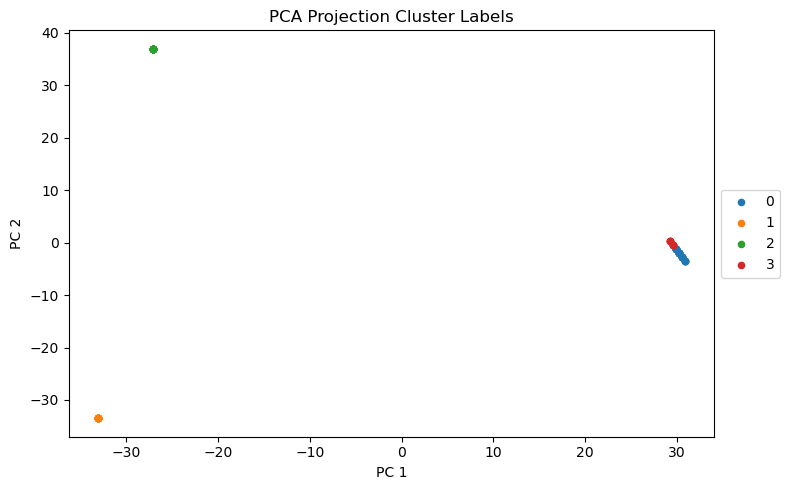

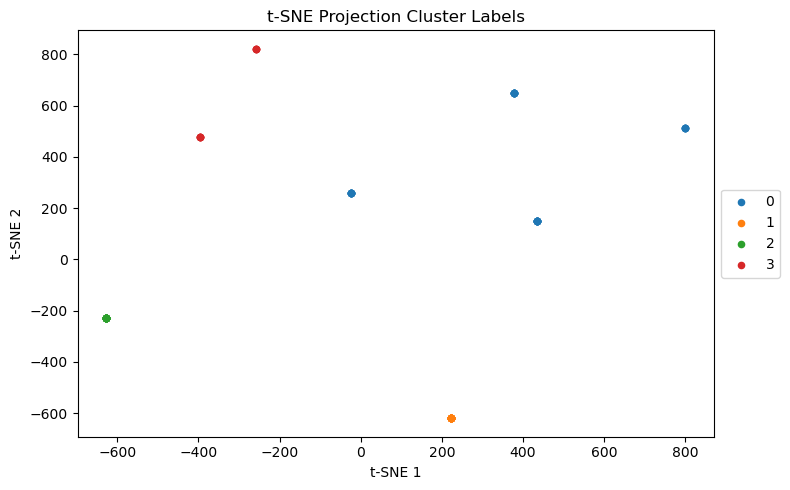

In [108]:
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (cluster_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection Cluster Labels')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    mask = (cluster_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection Cluster Labels')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [109]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 31 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 9 data points


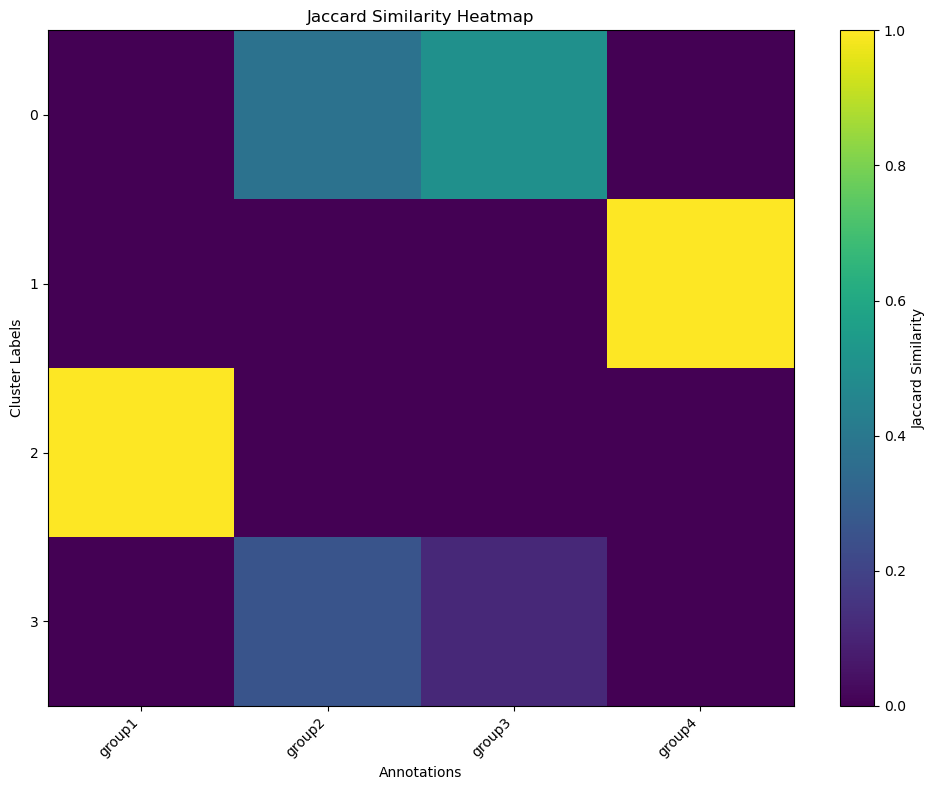

In [111]:
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
plot_heatmap(jaccard_matrix, labels2, labels1)

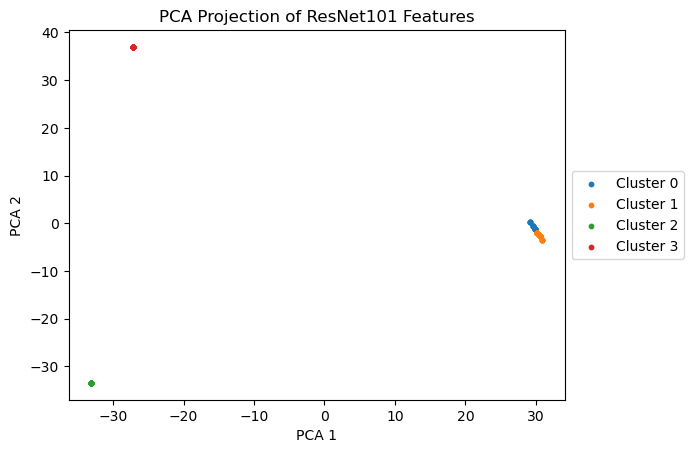

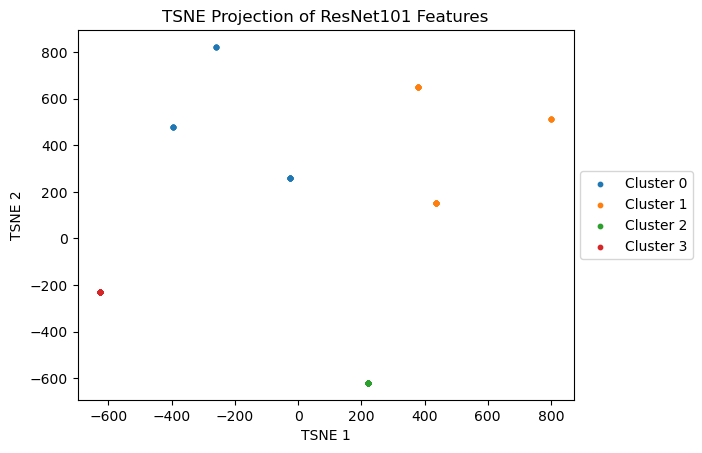

In [112]:
#Construct a k-Nearest Neighbors graph
knn_graph = kneighbors_graph(pcs, n_neighbors=20, metric='cosine', mode='connectivity', include_self=True)
#Convert the sparse matrix to a graph
G = nx.from_scipy_sparse_array(knn_graph)
# Perform Louvain clustering
partition = cl.best_partition(G)
#Compute the modularity of a partition of a graph
cl.modularity(partition, G)
#Extract cluster labels
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # PCA 1 values for this cluster
        embedding[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [113]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 17 data points
Cluster 1: 23 data points
Cluster 2: 20 data points
Cluster 3: 20 data points


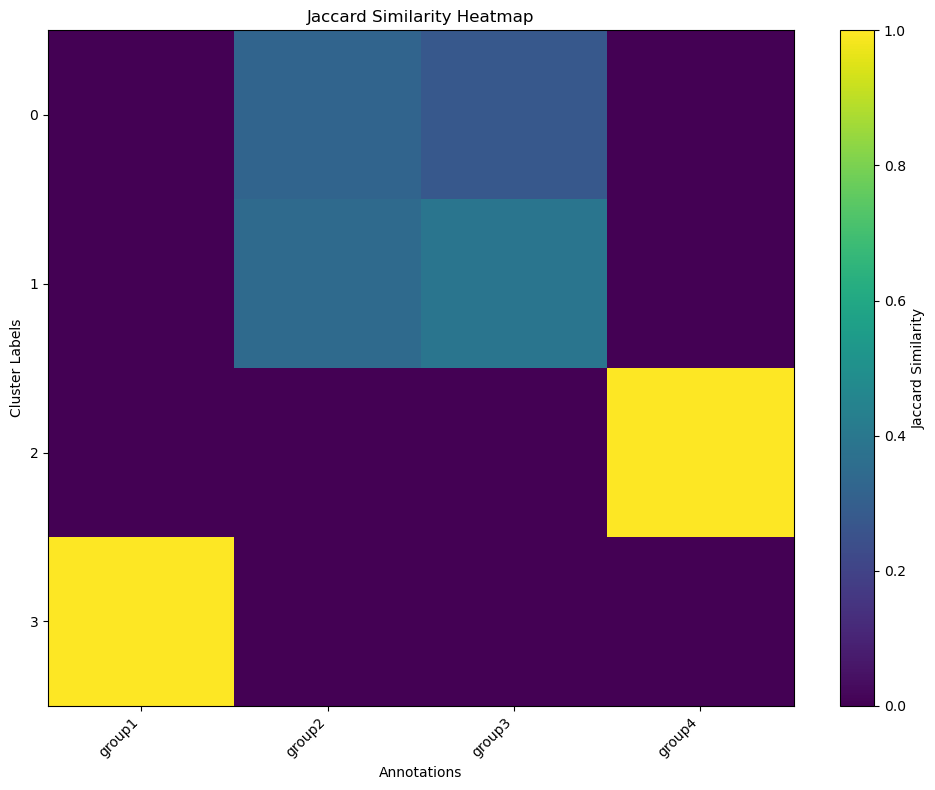

In [114]:
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
plot_heatmap(jaccard_matrix, labels2, labels1)

## CP1 Scaled

In [115]:
count_matrix = pd.read_csv("/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/cp1_count_matrix.csv", index_col=0)
#Perform PCA
pca = PCA(n_components=3, random_state=22)
pca.fit(count_matrix)
pcs = pca.transform(count_matrix)

In [81]:
count_matrix.shape

(80, 3)

In [50]:
count_matrix

,gene1,gene2,gene3
cell1,1.0,0.0,0.0
cell2,1.0,0.0,0.0
cell3,1.0,0.0,0.0
cell4,1.0,0.0,0.0
cell5,1.0,0.0,0.0
...,...,...,...
cell76,0.0,0.0,1.0
cell77,0.0,0.0,1.0
cell78,0.0,0.0,1.0
cell79,0.0,0.0,1.0


In [116]:
#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

In [117]:
#Number of clusters
n_clusters = 4

#Perform k-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(pcs)

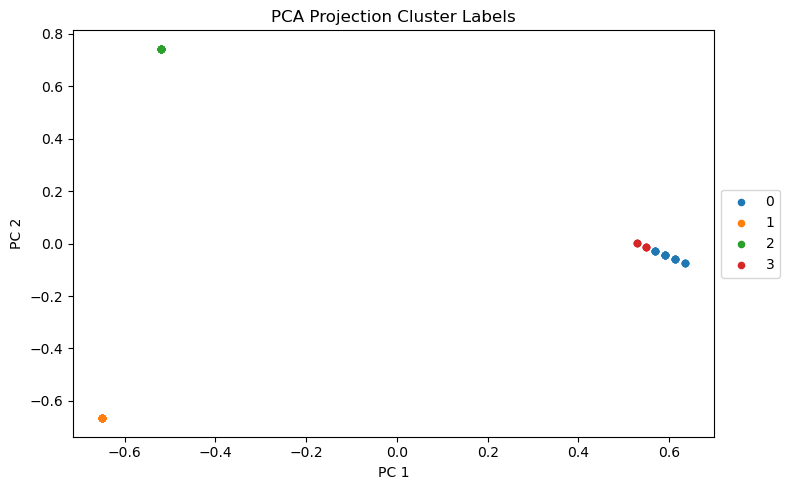

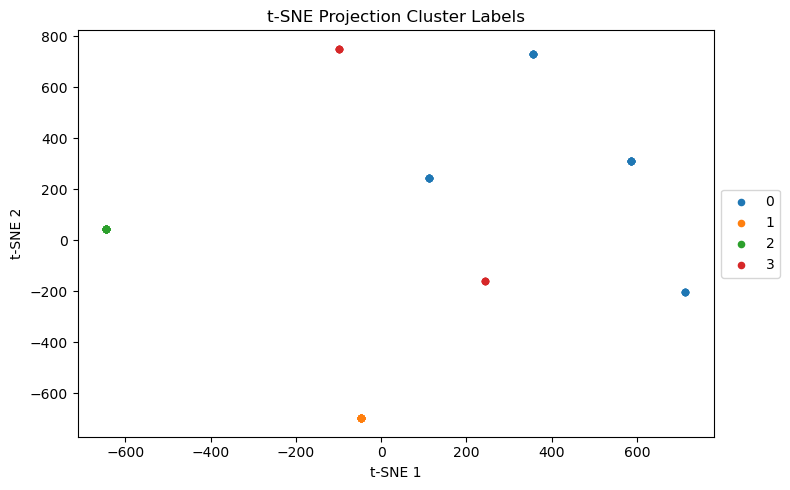

In [118]:
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (cluster_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection Cluster Labels')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    mask = (cluster_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection Cluster Labels')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [119]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 31 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 9 data points


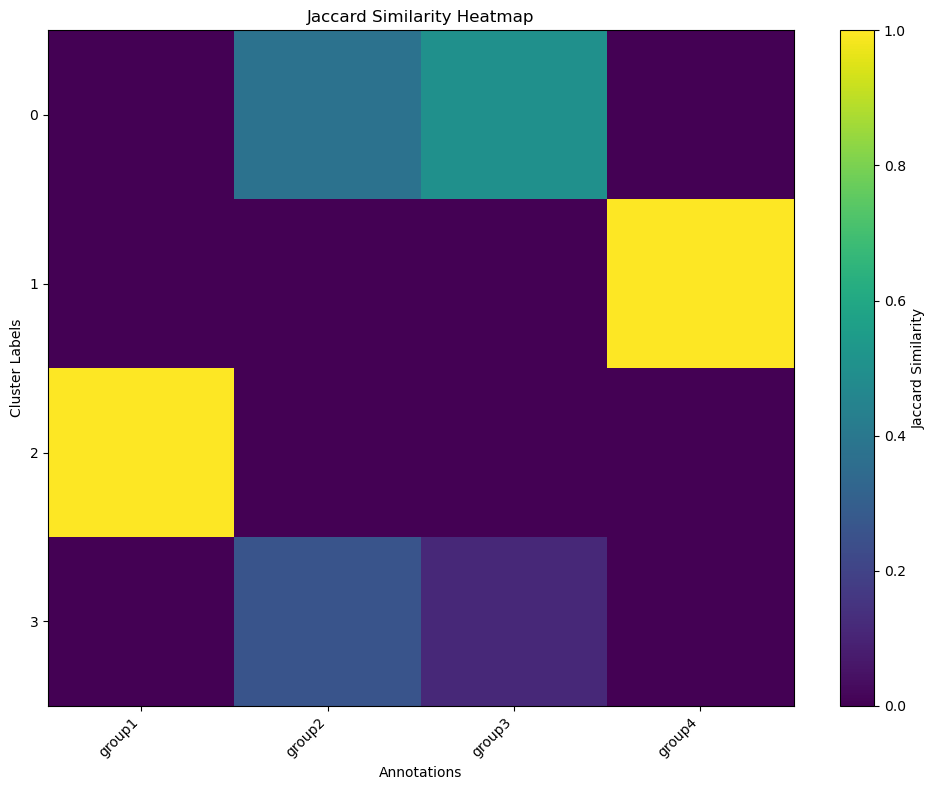

In [120]:
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
plot_heatmap(jaccard_matrix, labels2, labels1)

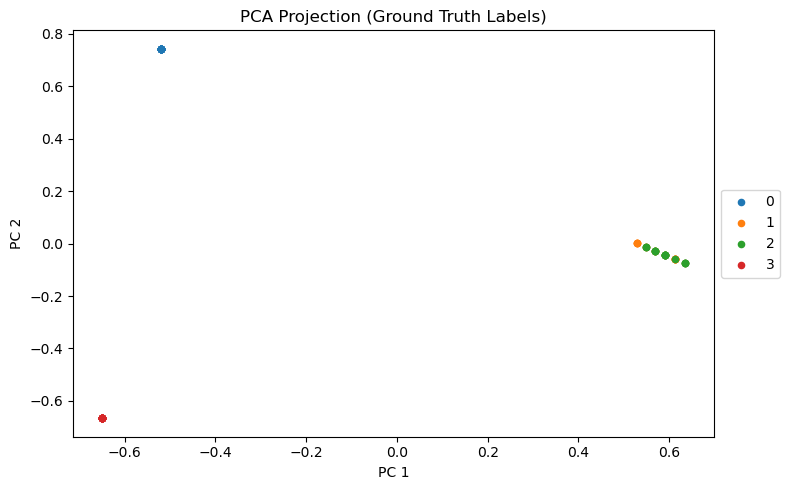

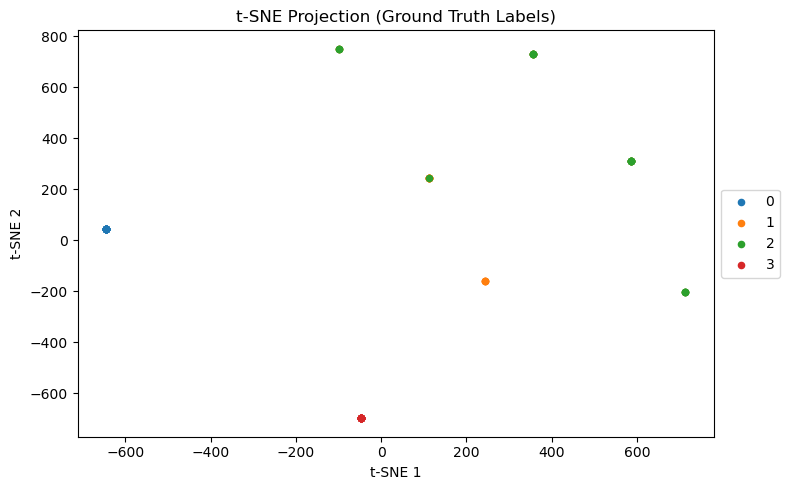

In [121]:
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [122]:
for label in np.unique(numeric_labels):
    count = np.sum(numeric_labels == label)
    print(f"Cluster {label}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 20 data points


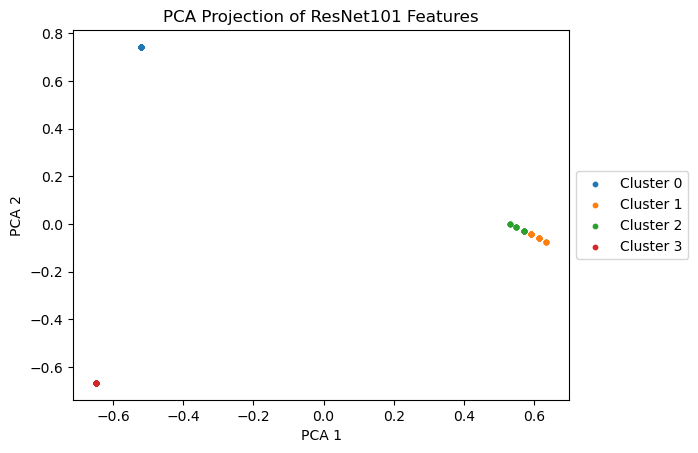

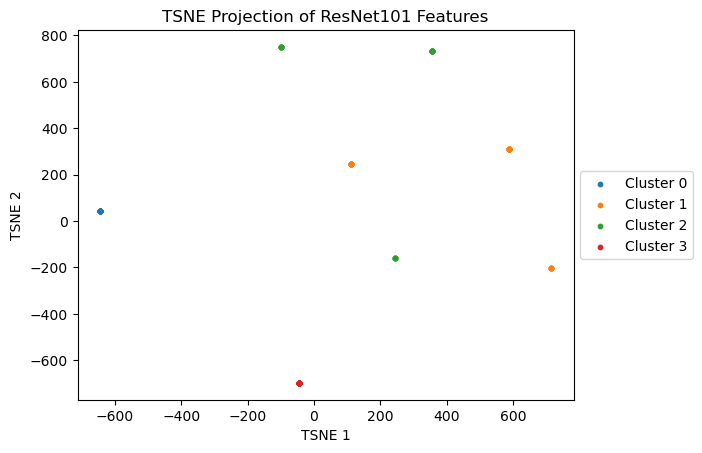

In [124]:
#Construct a k-Nearest Neighbors graph
knn_graph = kneighbors_graph(pcs, n_neighbors=15, metric='cosine', mode='connectivity', include_self=True)
#Convert the sparse matrix to a graph
G = nx.from_scipy_sparse_array(knn_graph)
# Perform Louvain clustering
partition = cl.best_partition(G)
#Compute the modularity of a partition of a graph
cl.modularity(partition, G)
#Extract cluster labels
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # PCA 1 values for this cluster
        embedding[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [125]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 23 data points
Cluster 2: 17 data points
Cluster 3: 20 data points


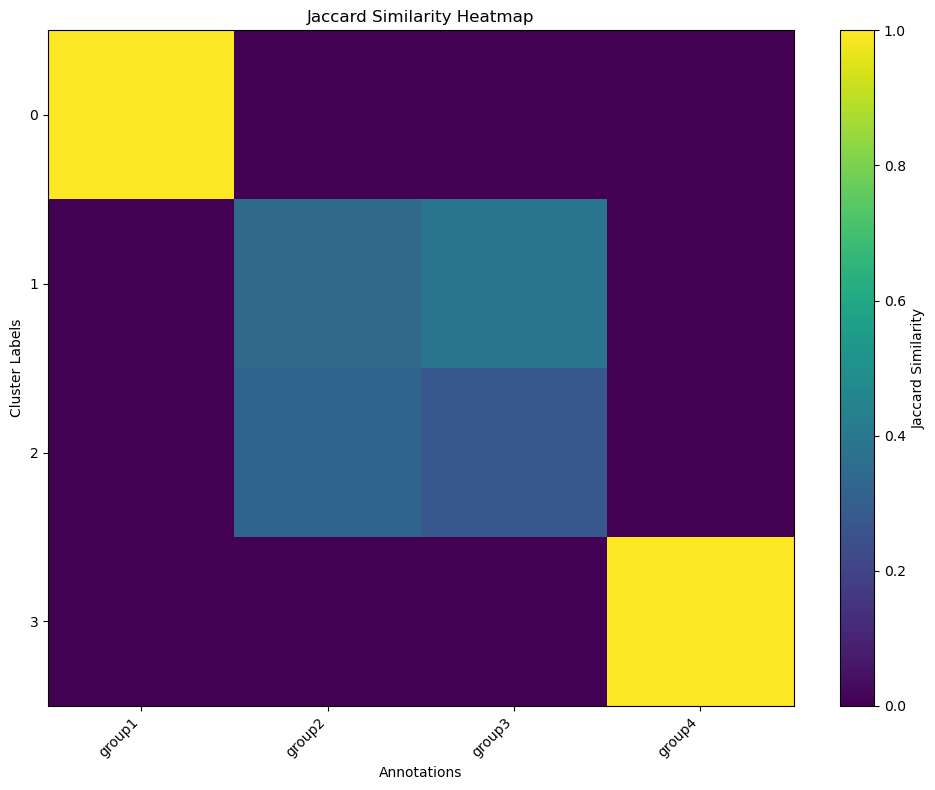

In [126]:
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
plot_heatmap(jaccard_matrix, labels2, labels1)

## Min-Max

In [127]:
count_matrix = pd.read_csv("/home/deev/t-simcne/CAP-CNN/data/simulation_caleb_nuclear_peri_withnoise2/min-max_count_matrix.csv", index_col=0)
#Perform PCA
pca = PCA(n_components=3, random_state=22)
pca.fit(count_matrix)
pcs = pca.transform(count_matrix)

In [128]:
#t-SNE dimensionality reduction
tsne = TSNE(n_components=2, random_state=42)
embedding = tsne.fit_transform(pcs)

In [129]:
#Number of clusters
n_clusters = 4

#Perform k-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(pcs)

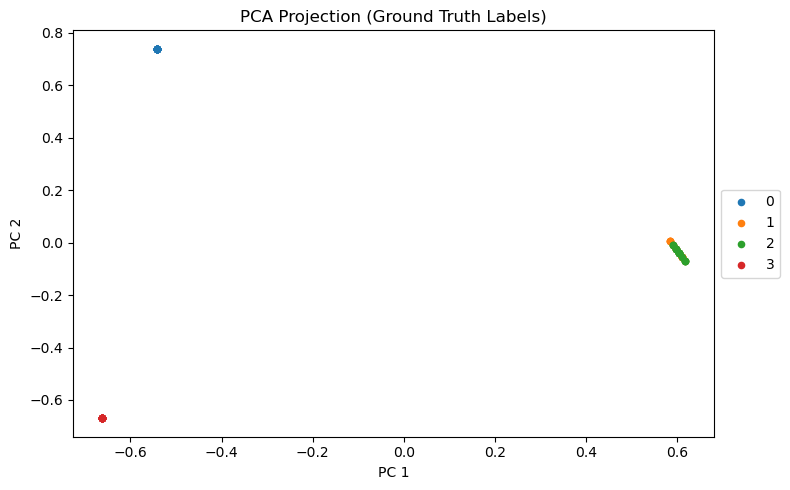

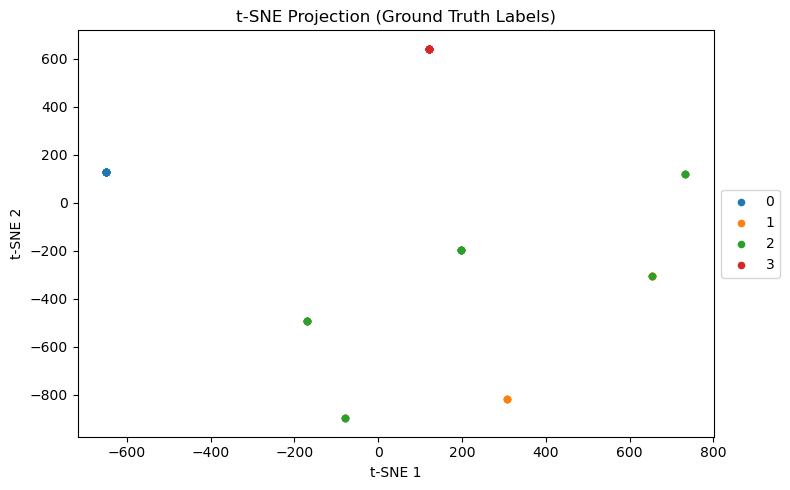

In [130]:
# --- PCA PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (numeric_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection (Ground Truth Labels)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(numeric_labels):
    mask = (numeric_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection (Ground Truth Labels)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [131]:
for label in np.unique(numeric_labels):
    count = np.sum(numeric_labels == label)
    print(f"Cluster {label}: {count} data points")

Cluster 0: 20 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 20 data points


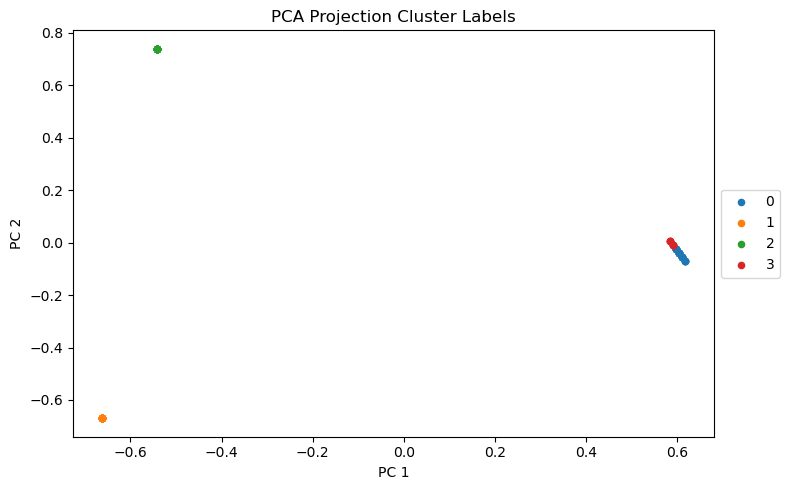

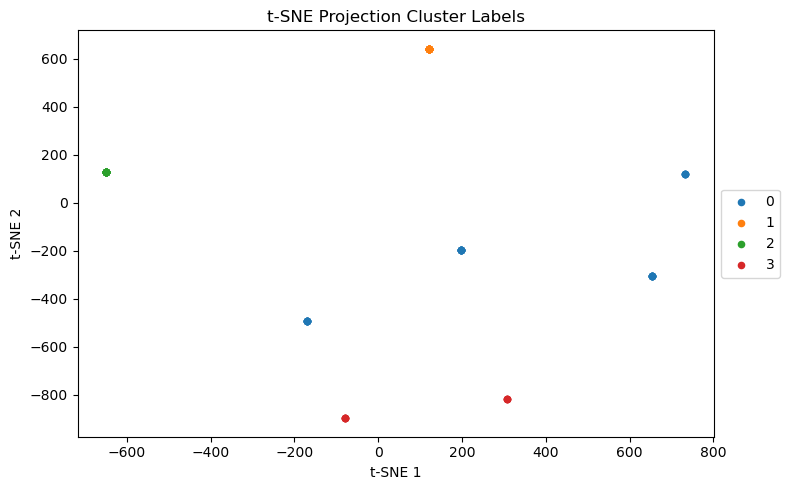

In [132]:
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    # Create a boolean mask for the rows belonging to this group
    mask = (cluster_labels == group_label)
    plt.scatter(
        pcs[mask, 0],   # PCA dimension 1
        pcs[mask, 1],   # PCA dimension 2
        label=group_label,
        s=20
    )
plt.title('PCA Projection Cluster Labels')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# --- TSNE PLOT WITH TRUE LABELS ---
plt.figure(figsize=(8, 5))
for group_label in np.unique(cluster_labels):
    mask = (cluster_labels == group_label)
    plt.scatter(
        embedding[mask, 0],  # t-SNE dimension 1
        embedding[mask, 1],  # t-SNE dimension 2
        label=group_label,
        s=20
    )
plt.title('t-SNE Projection Cluster Labels')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [133]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 31 data points
Cluster 1: 20 data points
Cluster 2: 20 data points
Cluster 3: 9 data points


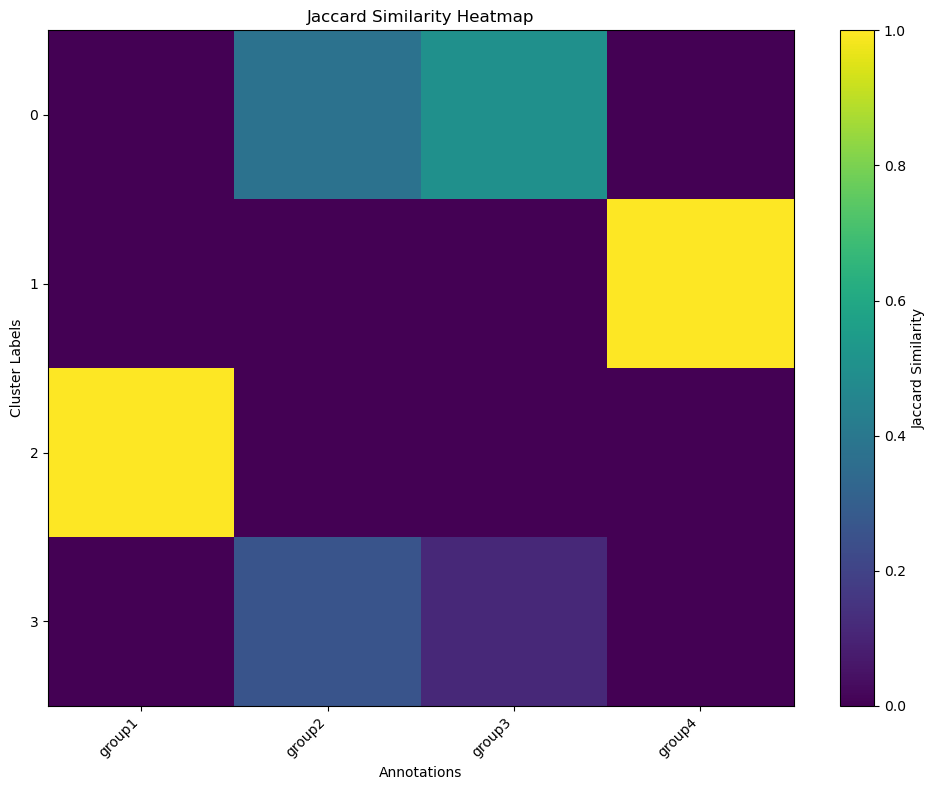

In [134]:
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
plot_heatmap(jaccard_matrix, labels2, labels1)

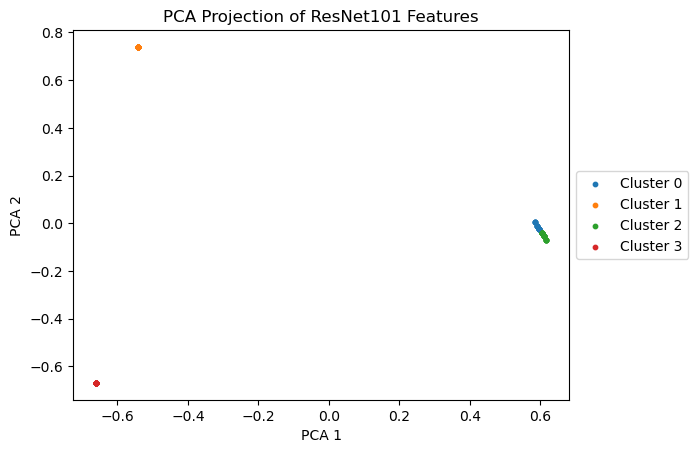

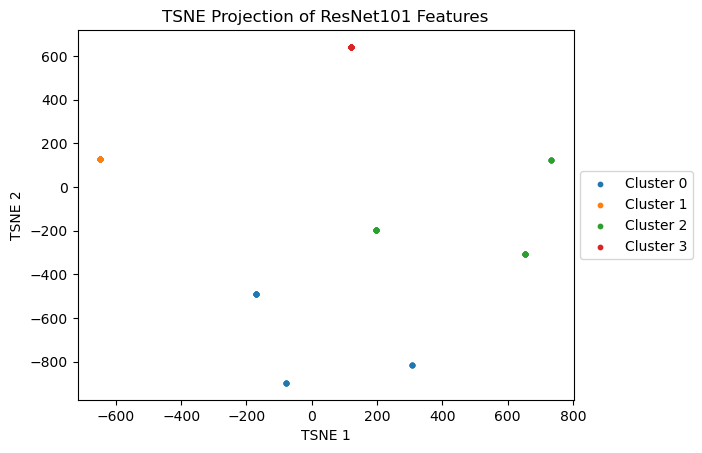

In [135]:
#Construct a k-Nearest Neighbors graph
knn_graph = kneighbors_graph(pcs, n_neighbors=20, metric='cosine', mode='connectivity', include_self=True)
#Convert the sparse matrix to a graph
G = nx.from_scipy_sparse_array(knn_graph)
# Perform Louvain clustering
partition = cl.best_partition(G)
#Compute the modularity of a partition of a graph
cl.modularity(partition, G)
#Extract cluster labels
cluster_labels = np.array(list(partition.values()))
unique_labels_2 = set(cluster_labels)


for label in unique_labels_2:
    plt.scatter(
        pcs[cluster_labels == label, 0],  # PCA 1 values for this cluster
        pcs[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('PCA Projection of ResNet101 Features')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

for label in unique_labels_2:
    plt.scatter(
        embedding[cluster_labels == label, 0],  # PCA 1 values for this cluster
        embedding[cluster_labels == label, 1],  # PCA 2 values for this cluster
        label=f'Cluster {label}',  # Label for legend
        marker='o', 
        s=10
    )
plt.title('TSNE Projection of ResNet101 Features')
plt.xlabel('TSNE 1')
plt.ylabel('TSNE 2')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

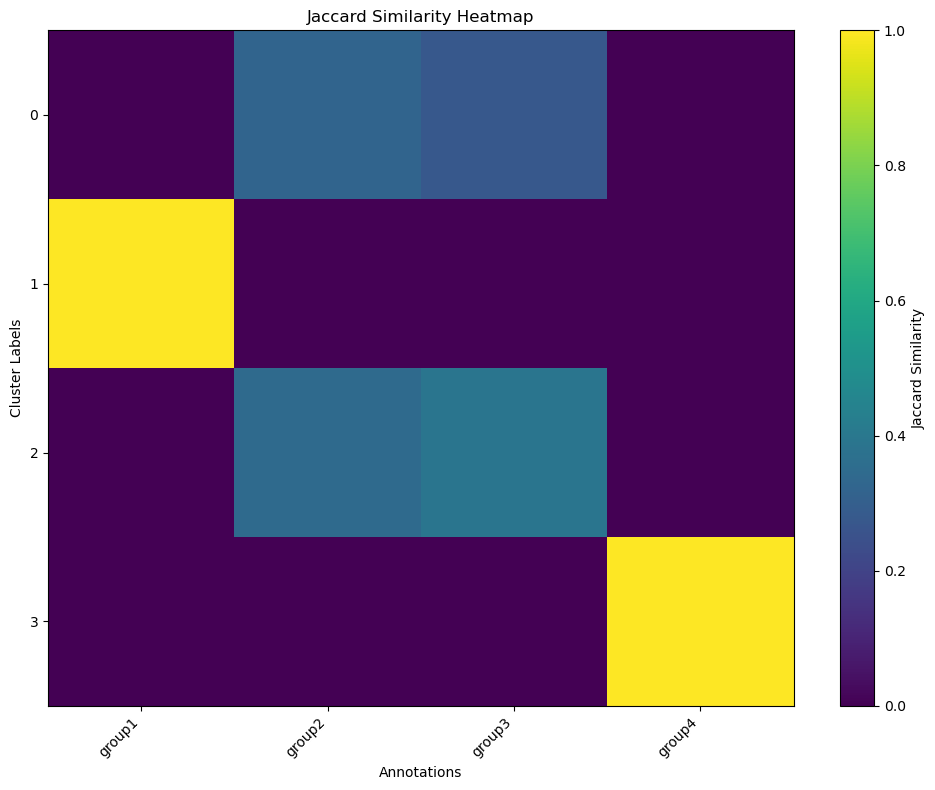

In [136]:
jaccard_matrix, labels1, labels2 = calculate_jaccard_similarity(cluster_labels, np.array(annotations))
plot_heatmap(jaccard_matrix, labels2, labels1)

In [137]:
for i in range(n_clusters):
    count = np.sum(cluster_labels == i)
    print(f"Cluster {i}: {count} data points")

Cluster 0: 17 data points
Cluster 1: 20 data points
Cluster 2: 23 data points
Cluster 3: 20 data points
